Guardado: curvas_sigma_lambda_16NT.csv   (3200, 4)
Guardado: curvas_sigma_lambda_16NT.png
Guardado: presion_interna_16NT.csv   (3200, 4)
Guardado: presion_interna_16NT.png
    subject  lambda_diastole  lambda_sistole
0         1         1.114382        1.151532
1         2         1.132489        1.171400
2         3         1.121975        1.182029
3         4         1.150288        1.212636
4         5         1.087443        1.150774
5         6         1.101943        1.149677
6         7         1.070350        1.135605
7         8         1.166085        1.200325
8         9         1.100315        1.146016
9        10         1.071320        1.115105
10       11         1.083632        1.122786
11       12         1.122435        1.161777
12       13         1.113663        1.157354
13       14         1.094233        1.146880
14       15         1.115471        1.156873
15       16         1.109699        1.139393
Guardado: curvas_fisiologicas_16NT.csv   (1600, 5)
Guardado: cu

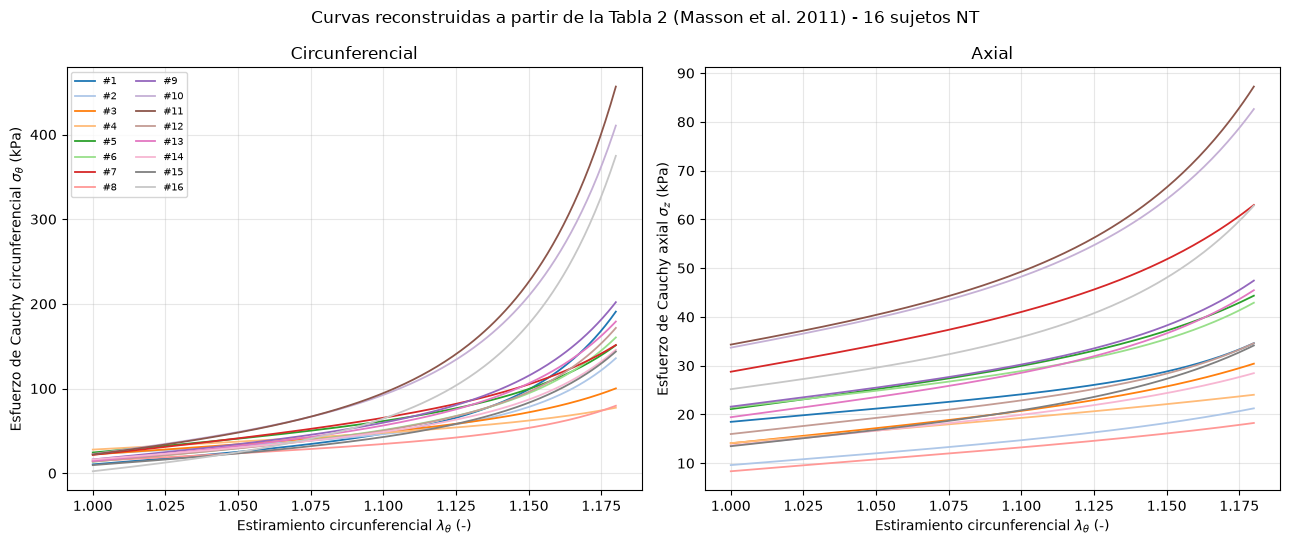

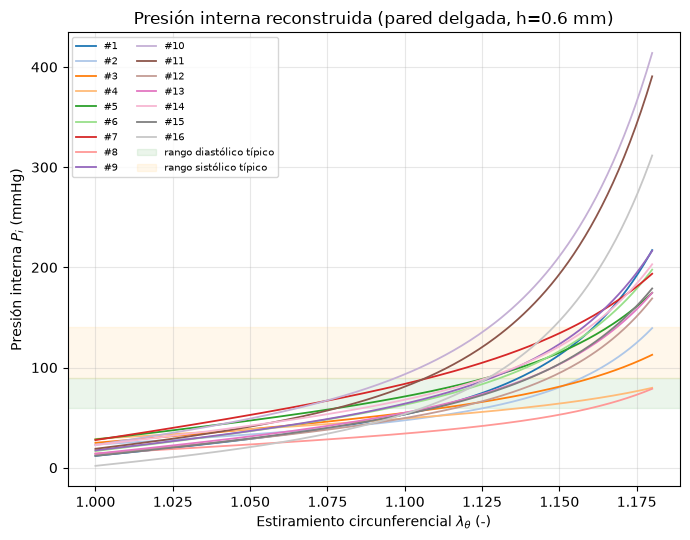

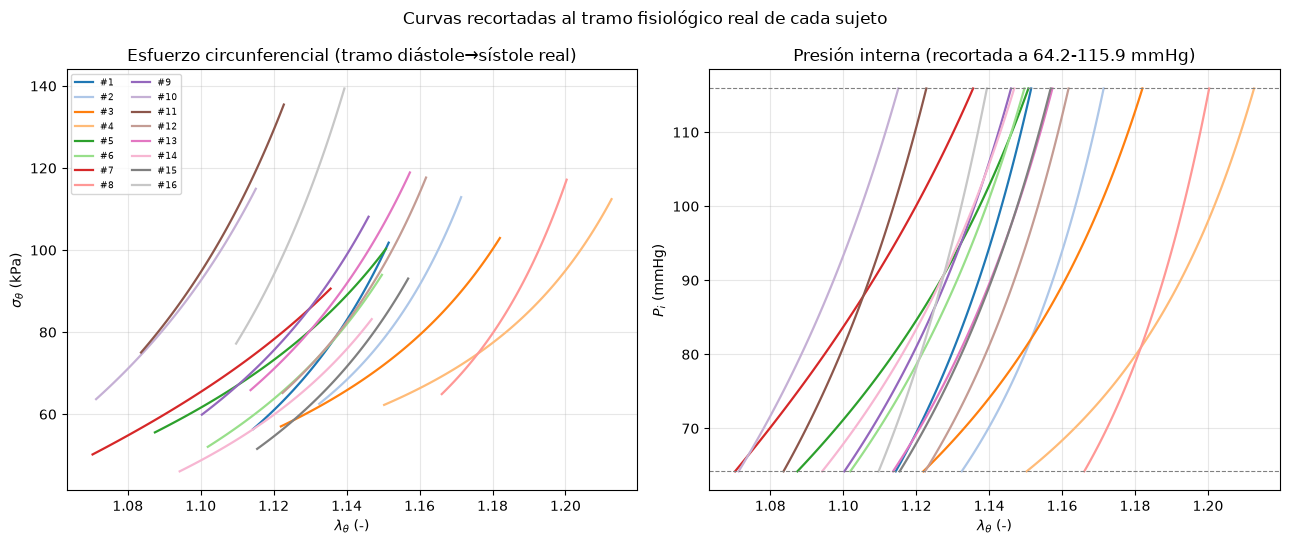

In [4]:
"""
Reconstrucción numérica de las curvas esfuerzo-estiramiento (sigma vs lambda)
de arteria carotida comun para los 16 sujetos normotensos de:

Masson I, Beaussier H, Boutouyrie P, Laurent S, Humphrey JD, Zidi M (2011)
"Carotid artery mechanical properties and stresses quantified using in vivo
data from normotensive and hypertensive humans"
Biomech Model Mechanobiol 10:867-882

Se evalua el modelo constitutivo anisotropico incompresible (elastina +
4 familias de fibras de colageno + tono activo de musculo liso), Ec. 4,
6-7 del paper (forma expandida: Ec. 8), con los parametros de mejor ajuste
por sujeto (Tabla 2).

SUPUESTO (necesario porque Tabla 2 no incluye la serie temporal de presion
sanguinea/perivascular Pi(t), Pa(t) usada en el problema de valores de
contorno original):
    Se impone incompresibilidad  lambda_r = 1 / (lambda_theta * lambda_z)
    y se fija el multiplicador de Lagrange p mediante sigma_rr = 0
    (convención estándar para obtener la curva "material" del modelo,
    independiente del problema de valores de contorno).
    lambda_z (axial) se mantiene fijo en el valor lambda de la Tabla 2
    para cada sujeto (asi lo trata el propio paper: parametro de
    estiramiento axial in vivo, no varia con el ciclo cardiaco).

Esto reproduce fielmente la FORMA y los PARAMETROS de cada sujeto; no
reproduce el offset exacto de la Fig. 5 del paper, que usa la presion
perivascular Pa(t) real medida en cada sujeto.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Cargar parametros por sujeto (Tabla 2)
# ------------------------------------------------------------------
df = pd.read_csv("tabla2_masson_NT.csv")


def sigma_theta_z(lambda_theta, lambda_z, c, c1, c2, c1circ, c2circ,
                   alpha_deg, Tm, lambda0, lambda_m):
    """
    Devuelve (sigma_theta, sigma_z) en kPa para un array de lambda_theta,
    con lambda_z fijo, evaluando la Ec. 8 de Masson et al. (2011).

    Familias de fibras k=1..4:
        k=1 axial          (alpha=0)    c1(1)=c1,     c2(1)=c2
        k=2 circunferencial(alpha=90)   c1(2)=c1circ, c2(2)=c2circ
        k=3 diagonal +alpha              c1(3)=c1,     c2(3)=c2
        k=4 diagonal -alpha              c1(4)=c1,     c2(4)=c2
    """
    alpha = np.deg2rad(alpha_deg)
    lambda_theta = np.asarray(lambda_theta, dtype=float)

    # incompresibilidad
    lambda_r = 1.0 / (lambda_theta * lambda_z)

    # estiramientos de fibra por familia
    lam1 = lambda_z * np.ones_like(lambda_theta)                       # axial
    lam2 = lambda_theta                                                 # circunf.
    lam3 = np.sqrt(lambda_theta**2 * np.sin(alpha)**2
                    + lambda_z**2 * np.cos(alpha)**2)                   # diagonal +
    lam4 = lam3                                                         # diagonal - (misma magnitud)

    fams = [
        (lam1, c1,     c2,     0.0),        # k=1 axial:            sin=0, cos=1
        (lam2, c1circ, c2circ, np.pi / 2),  # k=2 circunferencial:   sin=1, cos=0
        (lam3, c1,     c2,     alpha),      # k=3 diagonal +alpha
        (lam4, c1,     c2,     -alpha),     # k=4 diagonal -alpha
    ]

    sum_theta = np.zeros_like(lambda_theta)
    sum_z = np.zeros_like(lambda_theta)
    for lam_k, c1k, c2k, ang in fams:
        Ek = lam_k**2 - 1.0
        term = c1k * Ek * np.exp(c2k * Ek**2)
        sum_theta += term * np.sin(ang) ** 2
        sum_z += term * np.cos(ang) ** 2

    # multiplicador de Lagrange p, fijado por sigma_rr = 0  ->  p = c*lambda_r^2
    p = c * lambda_r**2

    sigma_theta = -p + c * lambda_theta**2 + lambda_theta**2 * sum_theta \
        + Tm * lambda_theta * (1.0 - ((lambda_m - lambda_theta) / (lambda_m - lambda0)) ** 2)

    sigma_z = -p + c * lambda_z**2 + lambda_z**2 * sum_z

    return sigma_theta, sigma_z


# ------------------------------------------------------------------
# 2) Reconstruir la curva de cada sujeto sobre un rango de lambda_theta
# ------------------------------------------------------------------
N_PUNTOS = 200
LAMBDA_MIN, LAMBDA_MAX = 1.00, 1.18   # rango comun a todos, cubre Fig. 5a del paper

lambda_theta_grid = np.linspace(LAMBDA_MIN, LAMBDA_MAX, N_PUNTOS)

resultados = {}   # subject -> dict con arrays
registros_csv = []

for _, row in df.iterrows():
    subj = int(row["subject"])
    sigma_th, sigma_z = sigma_theta_z(
        lambda_theta_grid,
        lambda_z=row["lambda_ax"],
        c=row["c_kPa"], c1=row["c1_kPa"], c2=row["c2"],
        c1circ=row["c1circ_kPa"], c2circ=row["c2circ"],
        alpha_deg=row["alpha_deg"],
        Tm=row["Tm_kPa"], lambda0=row["lambda0"], lambda_m=row["lambda_m"],
    )
    resultados[subj] = dict(lambda_theta=lambda_theta_grid,
                             sigma_theta=sigma_th, sigma_z=sigma_z)
    for lt, sth, sz in zip(lambda_theta_grid, sigma_th, sigma_z):
        registros_csv.append((subj, lt, sth, sz))

curvas_df = pd.DataFrame(registros_csv,
                          columns=["subject", "lambda_theta", "sigma_theta_kPa", "sigma_z_kPa"])
curvas_df.to_csv("curvas_sigma_lambda_16NT.csv", index=False)
print("Guardado: curvas_sigma_lambda_16NT.csv  ", curvas_df.shape)

# ------------------------------------------------------------------
# 3) Graficar (equivalente a Fig. 5a/5b del paper)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

cmap = plt.get_cmap("tab20")
for i, (subj, res) in enumerate(sorted(resultados.items())):
    color = cmap(i % 20)
    axes[0].plot(res["lambda_theta"], res["sigma_theta"], color=color, lw=1.3,
                 label=f"#{subj}")
    axes[1].plot(res["lambda_theta"], res["sigma_z"], color=color, lw=1.3,
                 label=f"#{subj}")

axes[0].set_xlabel(r"Estiramiento circunferencial $\lambda_\theta$ (-)")
axes[0].set_ylabel(r"Esfuerzo de Cauchy circunferencial $\sigma_\theta$ (kPa)")
axes[0].set_title("Circunferencial")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel(r"Estiramiento circunferencial $\lambda_\theta$ (-)")
axes[1].set_ylabel(r"Esfuerzo de Cauchy axial $\sigma_z$ (kPa)")
axes[1].set_title("Axial")
axes[1].grid(alpha=0.3)

axes[0].legend(ncol=2, fontsize=7, loc="upper left")
fig.suptitle("Curvas reconstruidas a partir de la Tabla 2 (Masson et al. 2011) - 16 sujetos NT")
fig.tight_layout()
fig.savefig("curvas_sigma_lambda_16NT.png", dpi=150)
print("Guardado: curvas_sigma_lambda_16NT.png")


# ------------------------------------------------------------------
# 4) Presion interna a partir de sigma_theta (Ec. 9 / 11 del paper)
# ------------------------------------------------------------------
#
# Ecuacion de equilibrio radial (Ec. 9, sin fuerzas de cuerpo):
#     d(sigma_rr)/dr + (sigma_rr - sigma_theta)/r = 0
#
# Integrando entre el radio interno r_i y el radio medial r_m, con
# sigma_rr(r_i) = -P_i  (presion sanguinea) y sigma_rr(r_m) = -P_a
# (presion perivascular, Ec. 10):
#
#     P_i = P_a + integral_{r_i}^{r_m}  (sigma_theta - sigma_rr) / r  dr
#
# LIMITACION: la Tabla 2 no da el espesor de pared (IMT) por sujeto,
# solo Rm (radio medial). Sin r_i no se puede integrar exactamente.
#
# APROXIMACION usada aqui (pared delgada): se asume que
# (sigma_theta - sigma_rr) es aprox. constante a traves del espesor
# h = IMT (igual a su valor ya calculado en r=Rm, con sigma_rr=0 por
# el supuesto de la seccion 2), y se integra 1/r exactamente:
#
#     P_i  ~=  sigma_theta(lambda_theta) * ln( Rm / (Rm - h) )
#
# h se deja como parametro editable (h_mm o h_over_Rm). Si consegis
# el IMT real de cada sujeto, reemplazar h_mm por un array por sujeto
# para un resultado exacto (dentro del supuesto de sigma_rr=0).

H_MM_DEFAULT = 0.6   # IMT tipico de literatura para CCA normotensa (mm) -- AJUSTAR si hay dato real
# Alternativa: fijar una razon h/Rm en vez de un valor absoluto
# H_OVER_RM = 0.13

registros_presion = []
for _, row in df.iterrows():
    subj = int(row["subject"])
    Rm = row["Rm_mm"]
    h = H_MM_DEFAULT
    ri = Rm - h
    factor_geom = np.log(Rm / ri)   # ln(rm/ri), del termino integrado 1/r

    sigma_th = resultados[subj]["sigma_theta"]
    Pi_kPa = sigma_th * factor_geom
    Pi_mmHg = Pi_kPa * 7.50062      # 1 kPa = 7.50062 mmHg

    for lt, p_kpa, p_mmhg in zip(lambda_theta_grid, Pi_kPa, Pi_mmHg):
        registros_presion.append((subj, lt, p_kpa, p_mmhg))

presion_df = pd.DataFrame(registros_presion,
                           columns=["subject", "lambda_theta", "Pi_kPa", "Pi_mmHg"])
presion_df.to_csv("presion_interna_16NT.csv", index=False)
print("Guardado: presion_interna_16NT.csv  ", presion_df.shape)

fig2, ax2 = plt.subplots(figsize=(7, 5.5))
for i, subj in enumerate(sorted(resultados.keys())):
    color = cmap(i % 20)
    sub = presion_df[presion_df.subject == subj]
    ax2.plot(sub["lambda_theta"], sub["Pi_mmHg"], color=color, lw=1.3, label=f"#{subj}")

ax2.axhspan(60, 90, color="green", alpha=0.08, label="rango diastólico típico")
ax2.axhspan(90, 140, color="orange", alpha=0.08, label="rango sistólico típico")
ax2.set_xlabel(r"Estiramiento circunferencial $\lambda_\theta$ (-)")
ax2.set_ylabel(r"Presión interna $P_i$ (mmHg)")
ax2.set_title(f"Presión interna reconstruida (pared delgada, h={H_MM_DEFAULT} mm)")
ax2.grid(alpha=0.3)
ax2.legend(ncol=2, fontsize=7, loc="upper left")
fig2.tight_layout()
fig2.savefig("presion_interna_16NT.png", dpi=150)
print("Guardado: presion_interna_16NT.png")


# ------------------------------------------------------------------
# 5) Recortar cada curva a su tramo fisiologico real (diastole -> sistole)
# ------------------------------------------------------------------
#
# La Tabla 2 no trae la presion sistolica/diastolica de cada sujeto
# individualmente (solo esta como promedio +/- DE del grupo NT en la
# Tabla 1: SBP = 115.9 +/- 13.1 mmHg, DBP = 64.2 +/- 9.2 mmHg,
# braquial). Se usa ese promedio del grupo como objetivo fisiologico
# comun, y se invierte la curva Pi(lambda_theta) DE CADA SUJETO
# (que ya reflejan su propia rigidez) para hallar el lambda_theta al
# que esa persona alcanza la diastolica y la sistolica de grupo.
# Esto da un tramo [lambda_dia, lambda_sys] distinto por sujeto:
# mas corto en los sujetos mas rigidos, mas largo en los mas blandos.

SBP_MMHG = 115.9   # Tabla 1, media grupo NT (n=16)
DBP_MMHG = 64.2    # Tabla 1, media grupo NT (n=16)

# Extender la grilla para asegurar que ambas presiones queden
# dentro del rango para todos los sujetos (algunos necesitan mas
# estiramiento que el 1.00-1.18 usado arriba)
LAMBDA_MIN_EXT, LAMBDA_MAX_EXT = 0.97, 1.35
lambda_ext = np.linspace(LAMBDA_MIN_EXT, LAMBDA_MAX_EXT, 2000)

tramos = []
curvas_recortadas = []
for _, row in df.iterrows():
    subj = int(row["subject"])
    sigma_th_ext, _ = sigma_theta_z(
        lambda_ext,
        lambda_z=row["lambda_ax"],
        c=row["c_kPa"], c1=row["c1_kPa"], c2=row["c2"],
        c1circ=row["c1circ_kPa"], c2circ=row["c2circ"],
        alpha_deg=row["alpha_deg"],
        Tm=row["Tm_kPa"], lambda0=row["lambda0"], lambda_m=row["lambda_m"],
    )
    Rm = row["Rm_mm"]
    ri = Rm - H_MM_DEFAULT
    factor_geom = np.log(Rm / ri)
    Pi_mmHg_ext = sigma_th_ext * factor_geom * 7.50062

    # curva monotona creciente -> inversion por interpolacion directa
    lam_dia = np.interp(DBP_MMHG, Pi_mmHg_ext, lambda_ext)
    lam_sys = np.interp(SBP_MMHG, Pi_mmHg_ext, lambda_ext)

    tramos.append((subj, lam_dia, lam_sys))

    # recalcular la curva sigma/presion SOLO dentro de [lam_dia, lam_sys]
    lam_fisio = np.linspace(lam_dia, lam_sys, 100)
    sigma_th_fisio, sigma_z_fisio = sigma_theta_z(
        lam_fisio,
        lambda_z=row["lambda_ax"],
        c=row["c_kPa"], c1=row["c1_kPa"], c2=row["c2"],
        c1circ=row["c1circ_kPa"], c2circ=row["c2circ"],
        alpha_deg=row["alpha_deg"],
        Tm=row["Tm_kPa"], lambda0=row["lambda0"], lambda_m=row["lambda_m"],
    )
    Pi_fisio_mmHg = sigma_th_fisio * factor_geom * 7.50062
    for lt, sth, sz, pmm in zip(lam_fisio, sigma_th_fisio, sigma_z_fisio, Pi_fisio_mmHg):
        curvas_recortadas.append((subj, lt, sth, sz, pmm))

tramos_df = pd.DataFrame(tramos, columns=["subject", "lambda_diastole", "lambda_sistole"])
tramos_df.to_csv("tramos_fisiologicos_16NT.csv", index=False)
print(tramos_df)

recortadas_df = pd.DataFrame(
    curvas_recortadas,
    columns=["subject", "lambda_theta", "sigma_theta_kPa", "sigma_z_kPa", "Pi_mmHg"])
recortadas_df.to_csv("curvas_fisiologicas_16NT.csv", index=False)
print("Guardado: curvas_fisiologicas_16NT.csv  ", recortadas_df.shape)

# Grafico: cada curva recortada a su propio tramo real
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5.5))
for i, subj in enumerate(sorted(resultados.keys())):
    color = cmap(i % 20)
    sub = recortadas_df[recortadas_df.subject == subj]
    axes3[0].plot(sub["lambda_theta"], sub["sigma_theta_kPa"], color=color, lw=1.6, label=f"#{subj}")
    axes3[1].plot(sub["lambda_theta"], sub["Pi_mmHg"], color=color, lw=1.6, label=f"#{subj}")

axes3[0].set_xlabel(r"$\lambda_\theta$ (-)")
axes3[0].set_ylabel(r"$\sigma_\theta$ (kPa)")
axes3[0].set_title("Esfuerzo circunferencial (tramo diástole→sístole real)")
axes3[0].grid(alpha=0.3)
axes3[0].legend(ncol=2, fontsize=6.5, loc="upper left")

axes3[1].set_xlabel(r"$\lambda_\theta$ (-)")
axes3[1].set_ylabel(r"$P_i$ (mmHg)")
axes3[1].set_title(f"Presión interna (recortada a {DBP_MMHG}-{SBP_MMHG} mmHg)")
axes3[1].axhline(DBP_MMHG, color="gray", ls="--", lw=0.8)
axes3[1].axhline(SBP_MMHG, color="gray", ls="--", lw=0.8)
axes3[1].grid(alpha=0.3)

fig3.suptitle("Curvas recortadas al tramo fisiológico real de cada sujeto")
fig3.tight_layout()
fig3.savefig("curvas_fisiologicas_16NT.png", dpi=150)
print("Guardado: curvas_fisiologicas_16NT.png")
